shape=(512, 512), ndim=2, dtype=float64


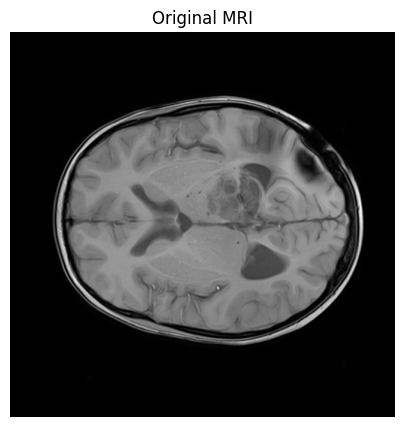

Nearest : MAE=1.333633  MSE=102.790245  RMSE=10.138552
Bilinear: MAE=2.093148  MSE=38.987883  RMSE=6.244028


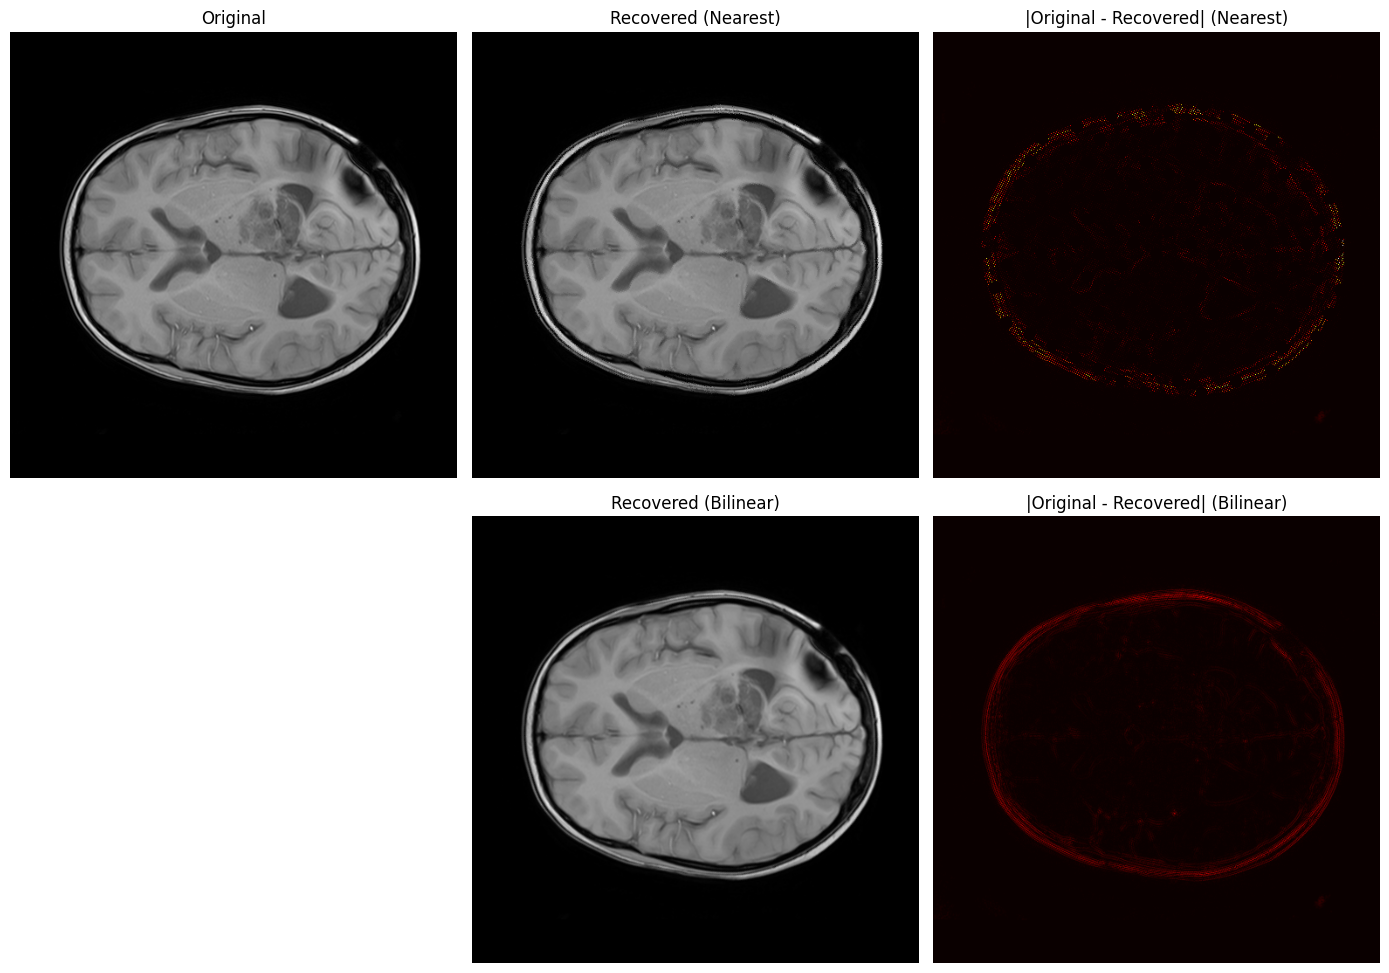

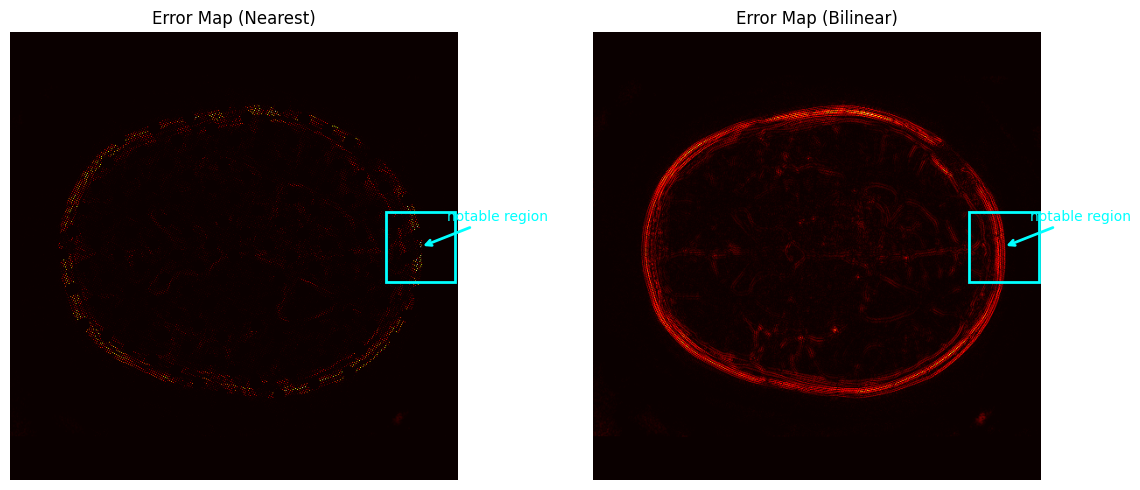

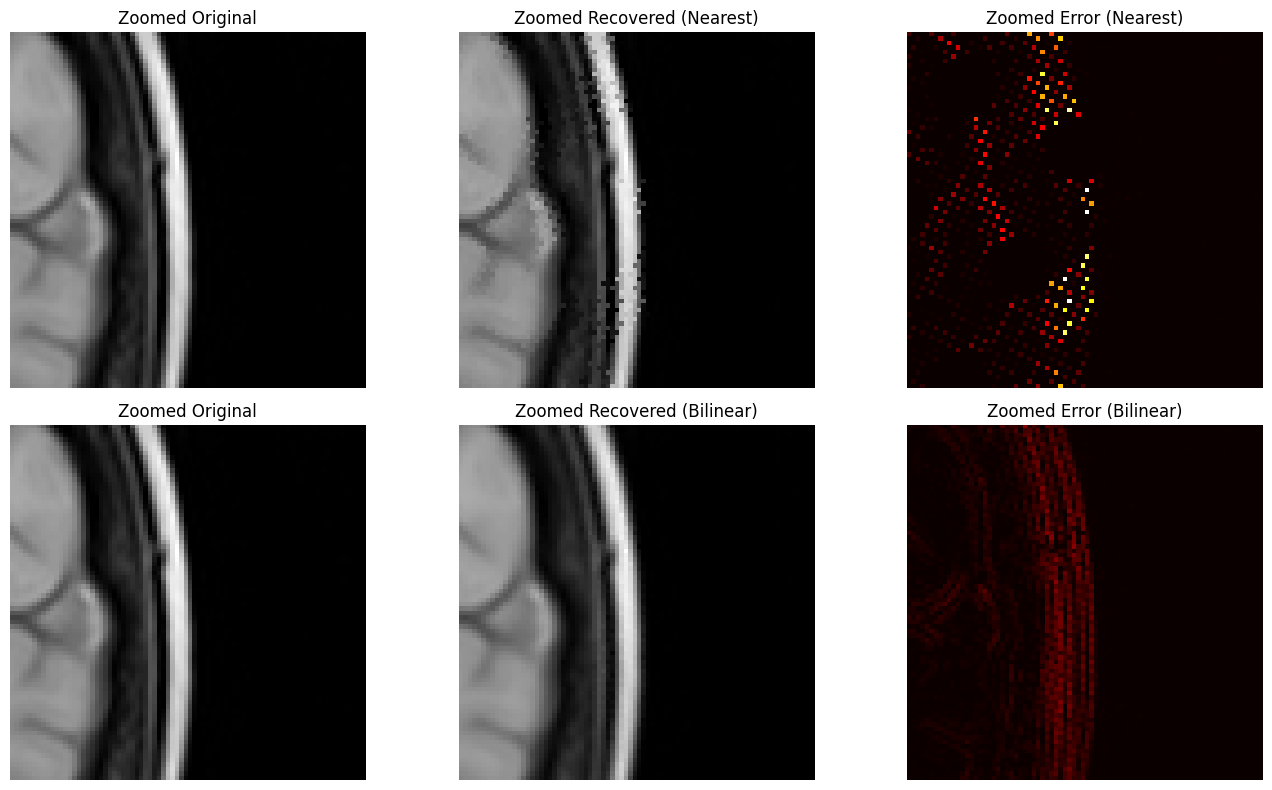

Highlighted center: (x=469, y=245)
Zoom box: x[429:509], y[205:285]


In [1]:
# Project 1

# ------------------------------
# 1) 导入数据
# ------------------------------
import numpy as np
import matplotlib.pyplot as plt

img = np.load("lab2_MRI.npy").astype(np.float64)

H, W = img.shape
print(f"shape={img.shape}, ndim={img.ndim}, dtype={img.dtype}")

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.title("Original MRI")
plt.axis("off")
plt.show()

# ------------------------------
# 2) 仿射旋转（矩阵）+ 两种插值
# ------------------------------
def get_rotation_matrix(theta, cx, cy):
    """3x3 齐次旋转矩阵：平移到原点 -> 旋转 -> 平移回去"""
    c, s = np.cos(theta), np.sin(theta)
    T1 = np.array([[1, 0, -cx],
                   [0, 1, -cy],
                   [0, 0, 1]], dtype=np.float64)
    R  = np.array([[c, -s, 0],
                   [s,  c, 0],
                   [0,  0, 1]], dtype=np.float64)
    T2 = np.array([[1, 0, cx],
                   [0, 1, cy],
                   [0, 0, 1]], dtype=np.float64)
    return T2 @ R @ T1
def sample_nearest(im, x, y):
    h, w = im.shape
    xi, yi = int(np.rint(x)), int(np.rint(y))
    if xi < 0 or xi >= w or yi < 0 or yi >= h:
        return 0.0
    return im[yi, xi]
def sample_bilinear(im, x, y):
    h, w = im.shape
    x0, y0 = int(np.floor(x)), int(np.floor(y))
    x1, y1 = x0 + 1, y0 + 1
    if x0 < 0 or y0 < 0 or x1 >= w or y1 >= h:
        return 0.0
    dx, dy = x - x0, y - y0
    v00, v10 = im[y0, x0], im[y0, x1]
    v01, v11 = im[y1, x0], im[y1, x1]
    return ((1 - dx) * (1 - dy) * v00 +
            dx * (1 - dy) * v10 +
            (1 - dx) * dy * v01 +
            dx * dy * v11)
def warp_affine_inverse(im, M, mode="nearest"):
    """
    逆向映射：
    对输出图每个像素，用 inv(M) 映射回输入图再插值取值
    """
    h, w = im.shape
    out = np.zeros((h, w), dtype=np.float64)
    Minv = np.linalg.inv(M)
    for v in range(h):
        for u in range(w):
            x, y, _ = Minv @ np.array([u, v, 1.0], dtype=np.float64)
            if mode == "nearest":
                out[v, u] = sample_nearest(im, x, y)
            elif mode == "bilinear":
                out[v, u] = sample_bilinear(im, x, y)
            else:
                raise ValueError("mode must be 'nearest' or 'bilinear'")
    return out

theta = np.pi / 5
cx, cy = (W - 1) / 2.0, (H - 1) / 2.0
M_pos = get_rotation_matrix(theta, cx, cy)
M_neg = get_rotation_matrix(-theta, cx, cy)
# 最近邻：正转 -> 反转
rot_nn = warp_affine_inverse(img, M_pos, mode="nearest")
rec_nn = warp_affine_inverse(rot_nn, M_neg, mode="nearest")
# 双线性：正转 -> 反转
rot_bl = warp_affine_inverse(img, M_pos, mode="bilinear")
rec_bl = warp_affine_inverse(rot_bl, M_neg, mode="bilinear")
# 绝对误差图
diff_nn = np.abs(img - rec_nn)
diff_bl = np.abs(img - rec_bl)
def metrics(err):
    mae = np.mean(np.abs(err))
    mse = np.mean(err ** 2)
    rmse = np.sqrt(mse)
    return mae, mse, rmse
mae_nn, mse_nn, rmse_nn = metrics(img - rec_nn)
mae_bl, mse_bl, rmse_bl = metrics(img - rec_bl)
print("Nearest : MAE=%.6f  MSE=%.6f  RMSE=%.6f" % (mae_nn, mse_nn, rmse_nn))
print("Bilinear: MAE=%.6f  MSE=%.6f  RMSE=%.6f" % (mae_bl, mse_bl, rmse_bl))
# 可视化
vmax = max(np.max(diff_nn), np.max(diff_bl), 1e-8)
plt.figure(figsize=(14, 10))
plt.subplot(2, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")
plt.subplot(2, 3, 2)
plt.imshow(rec_nn, cmap="gray")
plt.title("Recovered (Nearest)")
plt.axis("off")
plt.subplot(2, 3, 3)
plt.imshow(diff_nn, cmap="hot", vmin=0, vmax=vmax)
plt.title("|Original - Recovered| (Nearest)")
plt.axis("off")
plt.subplot(2, 3, 5)
plt.imshow(rec_bl, cmap="gray")
plt.title("Recovered (Bilinear)")
plt.axis("off")
plt.subplot(2, 3, 6)
plt.imshow(diff_bl, cmap="hot", vmin=0, vmax=vmax)
plt.title("|Original - Recovered| (Bilinear)")
plt.axis("off")
plt.tight_layout()
plt.show()

# ------------------------------
# 5) 箭头高亮差异区域 + 局部放大
# 依赖前面已算好的：img, rec_nn, rec_bl, diff_nn, diff_bl
# ------------------------------

from matplotlib.patches import Rectangle
# 两种方法“恢复误差差异”图：越大表示两种插值差异越明显
delta = np.abs(diff_nn - diff_bl)

# 找差异最大的点（避免边缘，防止放大框越界）
margin = 40
core = delta[margin:-margin, margin:-margin]
peak_idx = np.unravel_index(np.argmax(core), core.shape)
cy_peak, cx_peak = peak_idx[0] + margin, peak_idx[1] + margin

# 放大框大小
box = 80
x0 = max(cx_peak - box // 2, 0)
y0 = max(cy_peak - box // 2, 0)
x1 = min(x0 + box, img.shape[1])
y1 = min(y0 + box, img.shape[0])

# 为了保证框是 box*box，必要时回调起点
x0 = max(x1 - box, 0)
y0 = max(y1 - box, 0)

# ------- 主图：在误差图上画箭头和框 -------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(diff_nn, cmap="hot")
axes[0].set_title("Error Map (Nearest)")
axes[0].axis("off")
axes[0].add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="cyan", linewidth=2))
axes[0].annotate(
    "notable region",
    xy=(cx_peak, cy_peak),
    xytext=(cx_peak + 30, cy_peak - 30),
    color="cyan",
    arrowprops=dict(arrowstyle="->", color="cyan", lw=2)
)

axes[1].imshow(diff_bl, cmap="hot")
axes[1].set_title("Error Map (Bilinear)")
axes[1].axis("off")
axes[1].add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="cyan", linewidth=2))
axes[1].annotate(
    "notable region",
    xy=(cx_peak, cy_peak),
    xytext=(cx_peak + 30, cy_peak - 30),
    color="cyan",
    arrowprops=dict(arrowstyle="->", color="cyan", lw=2)
)

plt.tight_layout()
plt.show()

# ------- 局部放大对比 -------
crop_img = img[y0:y1, x0:x1]
crop_nn  = rec_nn[y0:y1, x0:x1]
crop_bl  = rec_bl[y0:y1, x0:x1]
crop_dnn = diff_nn[y0:y1, x0:x1]
crop_dbl = diff_bl[y0:y1, x0:x1]

vmax = max(crop_dnn.max(), crop_dbl.max(), 1e-8)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].imshow(crop_img, cmap="gray")
axes[0, 0].set_title("Zoomed Original")
axes[0, 0].axis("off")

axes[0, 1].imshow(crop_nn, cmap="gray")
axes[0, 1].set_title("Zoomed Recovered (Nearest)")
axes[0, 1].axis("off")

axes[0, 2].imshow(crop_dnn, cmap="hot", vmin=0, vmax=vmax)
axes[0, 2].set_title("Zoomed Error (Nearest)")
axes[0, 2].axis("off")

axes[1, 0].imshow(crop_img, cmap="gray")
axes[1, 0].set_title("Zoomed Original")
axes[1, 0].axis("off")

axes[1, 1].imshow(crop_bl, cmap="gray")
axes[1, 1].set_title("Zoomed Recovered (Bilinear)")
axes[1, 1].axis("off")

axes[1, 2].imshow(crop_dbl, cmap="hot", vmin=0, vmax=vmax)
axes[1, 2].set_title("Zoomed Error (Bilinear)")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

print(f"Highlighted center: (x={cx_peak}, y={cy_peak})")
print(f"Zoom box: x[{x0}:{x1}], y[{y0}:{y1}]")

- Purpose: 使用矩阵仿射变换完成 MRI 图像的正向旋转与反向旋转，对比最近邻和双线性插值在信息保真上的差异。
- Step: 按 `+theta -> -theta` 执行两次逆向映射重采样，计算误差图和 MAE/MSE/RMSE，并对差异区域做箭头标注与局部放大。
- Result: 最近邻为 `MAE=1.3336, MSE=102.7902, RMSE=10.1386`；双线性为 `MAE=2.0931, MSE=38.9879, RMSE=6.2440`。误差主要集中在组织边缘与旋转后外接区域。
- Conclusion: 双线性在 MSE/RMSE 上明显更优，说明其能更好抑制大误差、重建更稳定；最近邻边缘更“硬”，但更易产生锯齿和块状伪影。

shape=(512, 512), dtype=float64, min=0.000, max=255.000


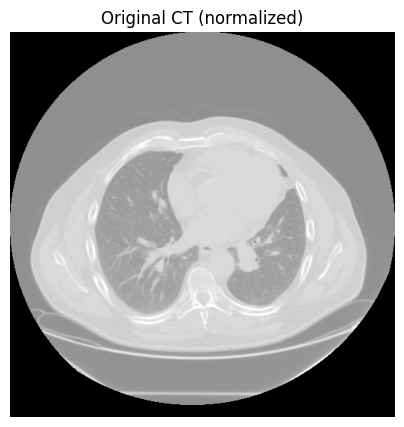

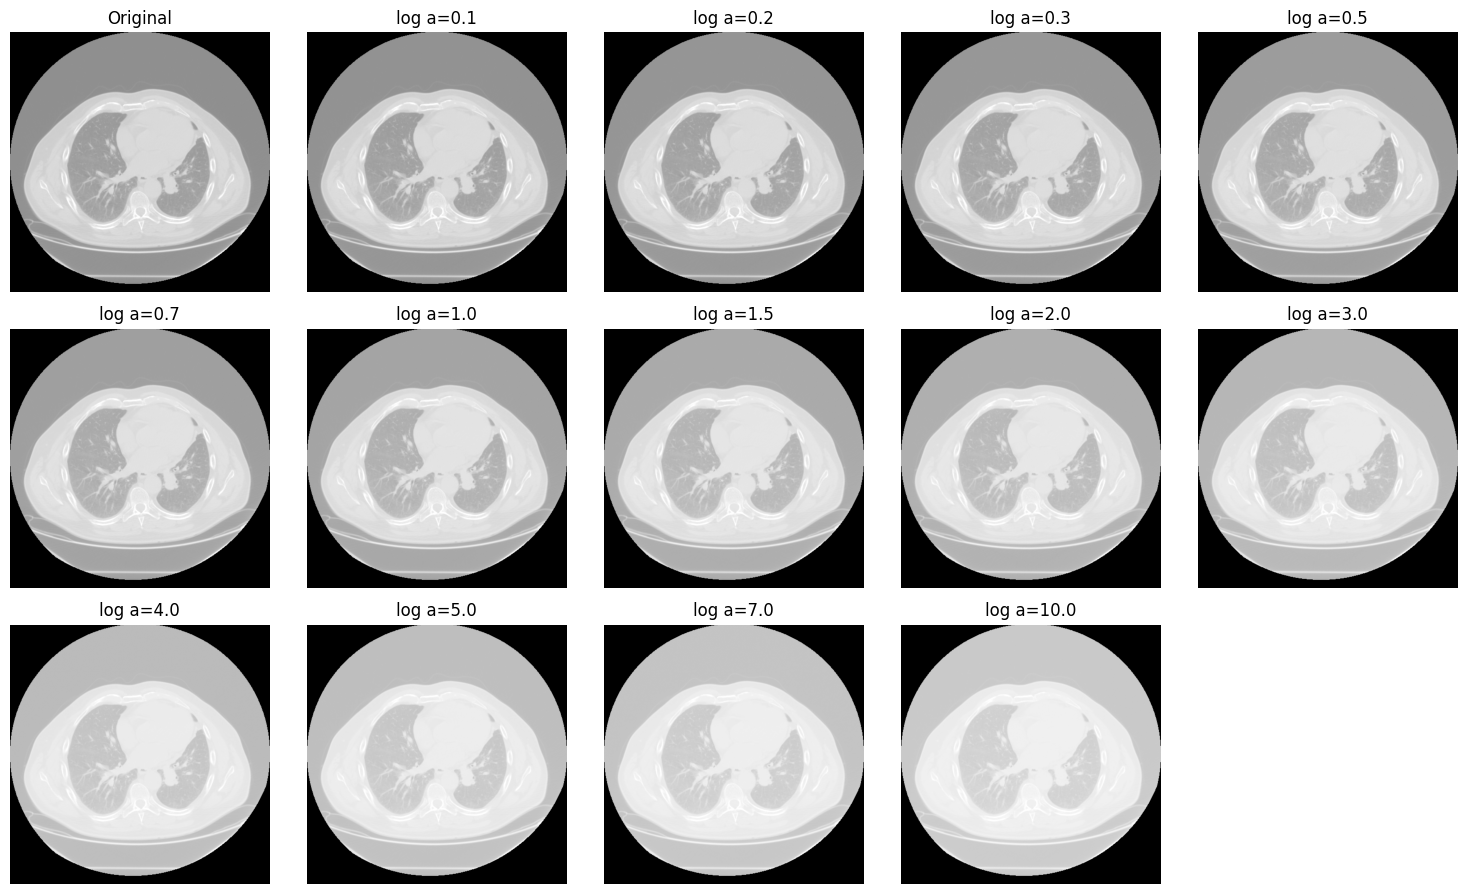

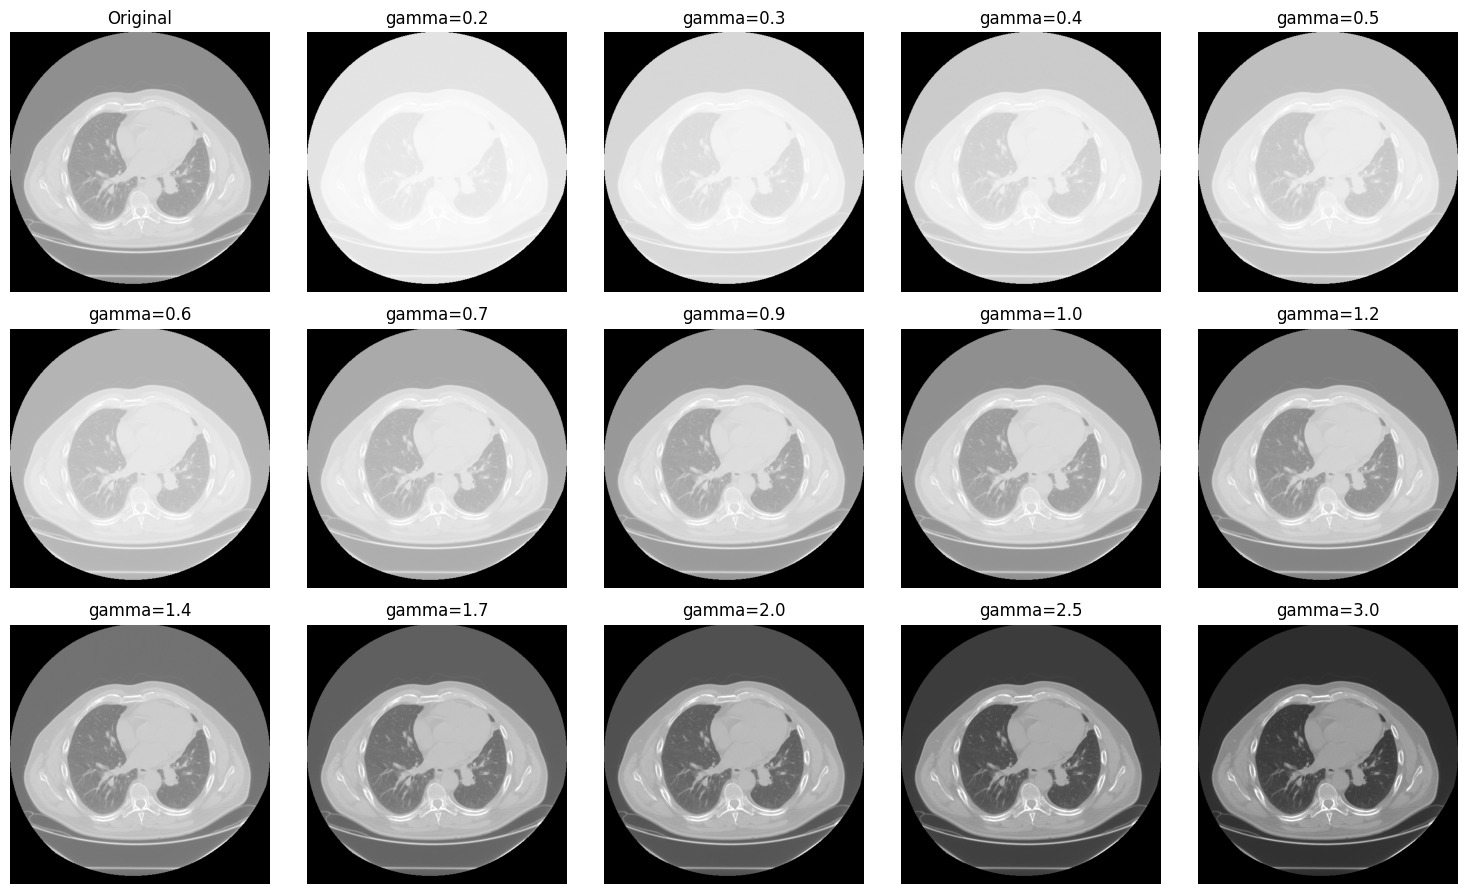

lung pixels: 62935 bone pixels: 128881


In [4]:
# project2

import numpy as np
import matplotlib.pyplot as plt

# 读取 CT 数据
ct = np.load("lab2_CT.npy").astype(np.float64)

# Min-Max 归一化到 [0, 1]
eps = 1e-8
ct_min, ct_max = ct.min(), ct.max()
ct_n = (ct - ct_min) / (ct_max - ct_min + eps)

print(f"shape={ct.shape}, dtype={ct.dtype}, min={ct_min:.3f}, max={ct_max:.3f}")

plt.figure(figsize=(5, 5))
plt.imshow(ct_n, cmap="gray")
plt.title("Original CT (normalized)")
plt.axis("off")
plt.show()

# Log 变换: s = c * log(1 + a * r)
def log_transform(img01, a=1.0, c=1.0):
    out = c * np.log1p(a * img01)
    # 重新归一化到 [0,1]，便于显示与比较
    out = (out - out.min()) / (out.max() - out.min() + 1e-8)
    return out

# Gamma / Power 变换: s = c * r^gamma
def power_transform(img01, gamma=1.0, c=1.0):
    out = c * np.power(img01, gamma)
    out = (out - out.min()) / (out.max() - out.min() + 1e-8)
    return out

# 一组 log 与 gamma 候选参数
a_list = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 7.0, 10.0]
g_list = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.9, 1.0, 1.2, 1.4, 1.7, 2.0, 2.5, 3.0]

# 1) Log 变换可视化
cols = 5
rows = int(np.ceil(len(a_list) / cols)) + 1
plt.figure(figsize=(3*cols, 3*rows))

plt.subplot(rows, cols, 1)
plt.imshow(ct_n, cmap="gray"); plt.title("Original"); plt.axis("off")

for i, a in enumerate(a_list, start=2):
    plt.subplot(rows, cols, i)
    out = log_transform(ct_n, a=a)
    plt.imshow(out, cmap="gray")
    plt.title(f"log a={a}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 2) Gamma 变换可视化
cols = 5
rows = int(np.ceil(len(g_list) / cols)) + 1
plt.figure(figsize=(3*cols, 3*rows))

plt.subplot(rows, cols, 1)
plt.imshow(ct_n, cmap="gray"); plt.title("Original"); plt.axis("off")

for i, g in enumerate(g_list, start=2):
    plt.subplot(rows, cols, i)
    out = power_transform(ct_n, gamma=g)
    plt.imshow(out, cmap="gray")
    plt.title(f"gamma={g}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 手动定义肺 / 骨 ROI 的矩形区域 [y0:y1, x0:x1]
H, W = ct_n.shape

lung_y0, lung_y1 = int(0.30 * H), int(0.70 * H)
lung_x0, lung_x1 = int(0.20 * W), int(0.80 * W)

bone_y0, bone_y1 = int(0.15 * H), int(0.85 * H)
bone_x0, bone_x1 = int(0.15 * W), int(0.85 * W)

lung_roi_mask = np.zeros_like(ct_n, dtype=bool)
lung_roi_mask[lung_y0:lung_y1, lung_x0:lung_x1] = True

bone_roi_mask = np.zeros_like(ct_n, dtype=bool)
bone_roi_mask[bone_y0:bone_y1, bone_x0:bone_x1] = True

print("lung pixels:", lung_roi_mask.sum(), "bone pixels:", bone_roi_mask.sum())


- Purpose: 在 CT 图像上设计 Log 与 Power(Gamma) 强度变换，比较参数变化对肺组织与骨结构可见性的影响。
- Step: 对预设参数列表逐个变换，分别在 lung ROI 与 bone ROI 计算标准差（ROI-std）并选取最优参数，再做可视化对比。
- Result:两类组织的灰度分布和观察目标不同：肺部主要关注低灰区域中的细小纹理，骨组织主要关注高灰边缘与结构轮廓。所以分别针对肺组织与骨结构进行参数选择，而不是使用同一组全局参数。结合参数扫描结果与主观可读性对比，最终选取如下：肺组织采用 Gamma 变换 gamma=0.7、Log 变换 a=2.0；该组合能够有效提升暗部层次，使肺区纹理更清楚，同时避免 gamma 过小带来的噪声放大和“发灰”现象。骨结构采用 Gamma 变换 gamma=1.4、Log 变换 a=0.7；该组合可在压暗软组织背景的同时保持骨区高灰边界清晰，避免参数过大导致骨区过度压缩或饱和。
- Conclusion: 本实验对 CT 图像分别采用了对数变换（Log transform）与幂律变换（Power/Gamma transform）进行增强。两种方法都属于点运算，但灰度映射机制不同。Log 变换可写为 s = c * log(1 + a*r)，其中参数 a 决定映射曲线弯曲程度：一般会压缩高灰区、相对提升低灰区层次，适合抑制亮区过曝并展开暗部信息。Gamma 变换可写为 s = c * r^gamma，其中 gamma 直接控制亮暗趋势：gamma < 1 倾向提亮暗部，gamma > 1 倾向压暗低灰并相对突出高灰结构。因此，Log 的特点是“整体压缩 + 温和重分配”，而 Gamma 的特点是“方向性更强、调节更灵活”，两种方法并非互相替代，而是侧重不同：Log 更适合做稳健的全局灰度重分配，Gamma 更适合按观察目标做方向性增强。在本实验参数扫描中，Gamma 对 ROI 对比度变化更敏感，说明其在任务导向调参（看肺或看骨）中更具操作性。

raw shape: (747, 470, 4) ndim: 3


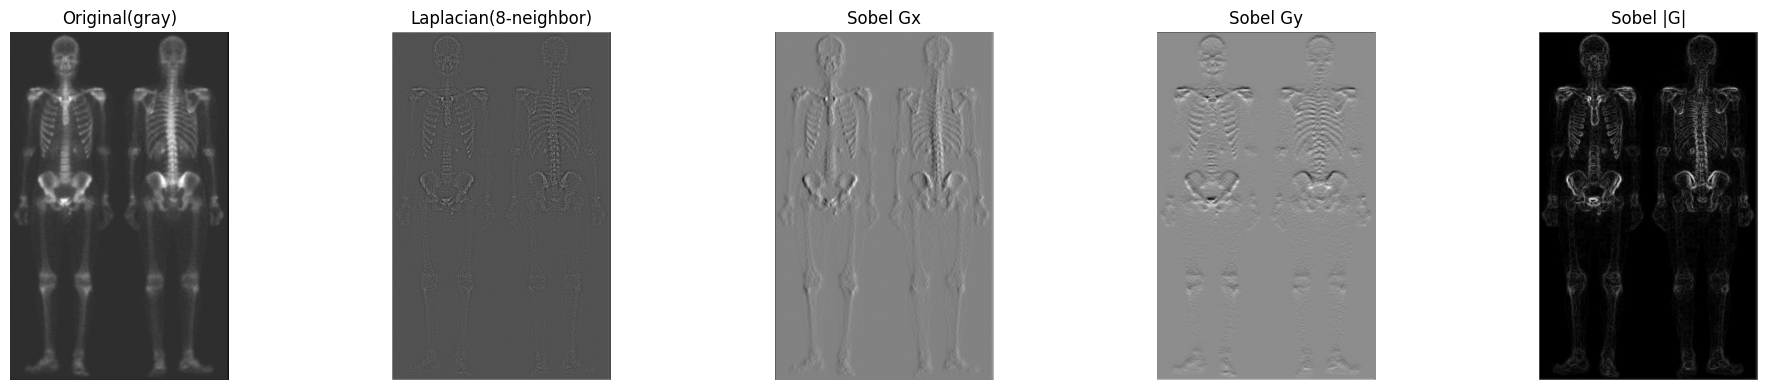

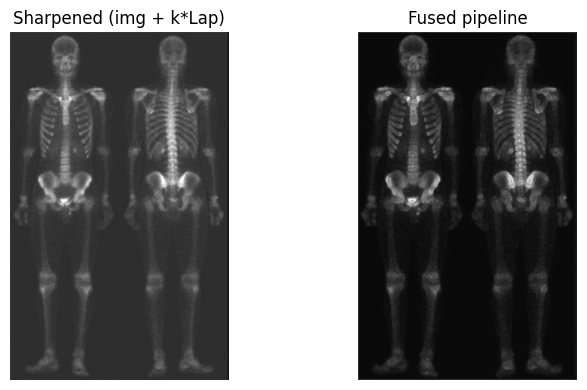

Laplacian std: 0.054504906854730806  | Gmag std: 0.1127719209352236


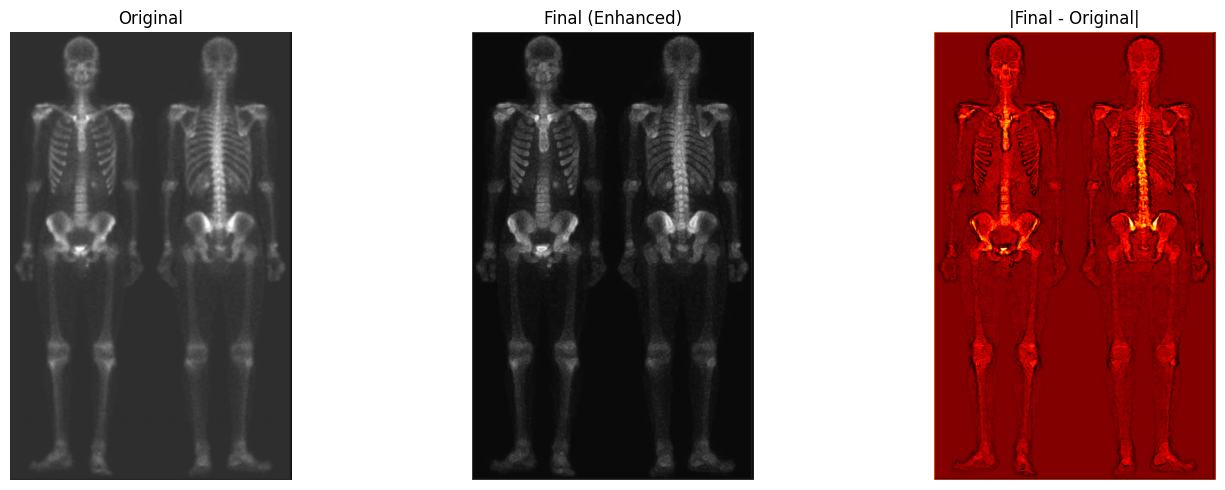

Original std: 0.09931395435559384
Final std   : 0.08861758825775115
Mean abs diff: 0.06747141440082885


In [4]:
# Project 3
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve as nd_convolve

def conv2_same(img2d, kernel2d):
    return nd_convolve(img2d, kernel2d, mode="constant", cval=0.0)

def to_gray(img):
    """支持 2D / RGB / RGBA，返回2D灰度"""
    if img.ndim == 2:
        return img.astype(np.float64)
    if img.ndim == 3:
        c = img.shape[2]
        if c == 1:
            return img[..., 0].astype(np.float64)
        if c >= 3:
            # ITU-R BT.601 常用灰度权重
            r, g, b = img[..., 0], img[..., 1], img[..., 2]
            return (0.299 * r + 0.587 * g + 0.114 * b).astype(np.float64)
    raise ValueError(f"Unsupported image shape: {img.shape}")

def norm01(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

# ---------- 1) 读入与预处理 ----------
xraw = np.load("lab2_filter.npy")
print("raw shape:", xraw.shape, "ndim:", xraw.ndim)

gray = to_gray(xraw)
img = norm01(gray)  # [0,1]

# ---------- 2) 8-neighbor Laplacian ----------
K_lap8 = np.array([[-1, -1, -1],
                   [-1,  8, -1],
                   [-1, -1, -1]], dtype=np.float64)
lap = conv2_same(img, K_lap8)

# ---------- 3) 3x3 Sobel x/y + 梯度幅值 ----------
K_sobel_x = np.array([[-1, 0, 1],
                      [-2, 0, 2],
                      [-1, 0, 1]], dtype=np.float64)
K_sobel_y = np.array([[-1, -2, -1],
                      [ 0,  0,  0],
                      [ 1,  2,  1]], dtype=np.float64)

Gx = conv2_same(img, K_sobel_x)
Gy = conv2_same(img, K_sobel_y)
Gmag = np.sqrt(Gx**2 + Gy**2)

# ---------- 4) 自行设计 pipeline：锐化 + 边缘融合 ----------
k_sharp = 0.15
sharp = np.clip(img + k_sharp * lap, 0, 1)

g_norm = norm01(Gmag)
alpha = 0.35
fused = np.clip((1 - alpha) * sharp + alpha * g_norm, 0, 1)

# ---------- 5) 显示 ----------
def show_row(titles, imgs, cmap="gray"):
    n = len(imgs)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]
    for ax, t, im in zip(axes, titles, imgs):
        ax.imshow(im, cmap=cmap)
        ax.set_title(t)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_row(
    ["Original(gray)", "Laplacian(8-neighbor)", "Sobel Gx", "Sobel Gy", "Sobel |G|"],
    [img, lap, Gx, Gy, Gmag]
)

show_row(
    ["Sharpened (img + k*Lap)", "Fused pipeline"],
    [sharp, fused]
)

print("Laplacian std:", float(lap.std()), " | Gmag std:", float(Gmag.std()))

diff = np.abs(fused - img)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(fused, cmap="gray")
axes[1].set_title("Final (Enhanced)")
axes[1].axis("off")
axes[2].imshow(diff, cmap="hot")
axes[2].set_title("|Final - Original|")
axes[2].axis("off")
plt.tight_layout()
plt.show()
print("Original std:", float(img.std()))
print("Final std   :", float(fused.std()))
print("Mean abs diff:", float(diff.mean()))

- Purpose: 使用 Laplacian 与 Sobel 高通信息提升 X-ray 图像结构边缘，完成图像增强流程设计。
- Step: 先计算 8 邻域 Laplacian 与 Sobel `Gx/Gy`，再构造 `sharp = img + k_sharp*lap` 与 `fused = (1-alpha)*sharp + alpha*g_norm` 得到最终增强图。
- Result: `Laplacian std=0.0545`，`Gmag std=0.1128`；最终 `Original std=0.0993`，`Final std=0.0886`，`Mean abs diff=0.0675`。视觉上边缘更清楚、骨架轮廓更突出。
- Conclusion: 本实验的增强流程采用“Laplacian 锐化 + Sobel 梯度补偿 + 加权融合”的设计思路，选择依据是：X-Ray 图像整体对比度偏低、边缘细节较弱，单一高通算子容易造成噪声放大或过锐化，因此需要将不同算子的优势进行组合。首先对原图进行 8 邻域 Laplacian 滤波，提取各向同性高频分量，用于突出骨骼和关节等结构边界；随后计算 3×3 Sobel 在 x/y 两方向的响应并合成为梯度幅值图，以增强方向性边缘与轮廓连续性；最后采用加权融合 fused = (1-α)·sharp + α·g_norm（其中 sharp = img + k·lap），在保留原图灰度层次的同时注入适量边缘信息。各步骤作用分别为：Laplacian 提供全局锐化能力，Sobel 提供稳定的边缘定位能力，加权融合用于平衡“细节增强”与“噪声控制”。从实验结果看，能有效提升骨结构与软组织边界可分性，同时避免仅使用单一高通算子时常见的纹理过硬和伪影问题。